# 12. Итоговая архитектура контура персонализации

Цель ноутбука — собрать в одном месте финальный результат текущей версии personalization loop:

- **Pair Generator:** `Semantic active v3`;
- **online update:** heuristic preference state update;
- **Preference Model:** online Logistic Preference Model, обучается параллельно по A/B-истории;
- **final vector:** калиброванный или смешанный с heuristic state preference vector.

В отличие от предыдущих ноутбуков, здесь мы не сравниваем все исследовательские ветки. Здесь проверяется именно выбранная архитектура и несколько вариантов финального preference vector.

In [2]:
from personalization.plotting import use_article_style
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.synthetic_dataset import load_synthetic_users_dataset
from personalization.preference_model_calibration import run_preference_model_calibration_batch_v4a2
from personalization.final_architecture_results import (
    final_architecture_description_table,
    summarize_final_architecture,
    compare_methods_vs_heuristic,
    summarize_method_improvements,
    save_final_architecture_tables,
    plot_final_architecture_diagram,
    plot_final_distance_by_target,
    plot_archetype_final_vector_comparison,
    plot_selected_vs_heuristic_improvement,
    plot_heldout_accuracy_by_target,
    plot_cosine_by_target,
)

use_article_style()


pd.set_option('display.max_columns', 120)

FIGURES_DIR = ROOT / 'outputs' / 'figures'
TABLES_DIR = ROOT / 'outputs' / 'tables'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
DATASET_PATH

WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization/outputs/datasets/synthetic_users_v21.csv')

## 1. Выбранная архитектура

Финальная логика текущей версии:

1. `Semantic active v3` задаёт A/B-вопросы.
2. `Heuristic update` стабильно ведёт `z_mean` во время сессии.
3. `Logistic Preference Model` параллельно обучается на истории A/B-ответов.
4. После сессии финальный вектор уточняется через калибровку или blend с модельным направлением.

Ключевой вывод из предыдущих экспериментов: Preference Model пока не стоит использовать как основной Pair Generator, но она полезна для уточнения итогового preference vector.

In [3]:
architecture_table = final_architecture_description_table()
architecture_table

,block,selected_component,role
0,Pair Generator,Semantic active v3,Generates informative semantic A/B questions u...
1,Online preference state,Heuristic update,Maintains stable z_mean trajectory during the ...
2,Parallel Preference Model,Online Logistic Preference Model,Learns preference direction from pairwise A/B ...
3,Final vector refinement,Selected: Blend 70/30,Combines stable heuristic state with calibrate...
4,Best Archetype 8D ablation,Norm-calibrated PM,Uses the Preference Model direction with heuri...


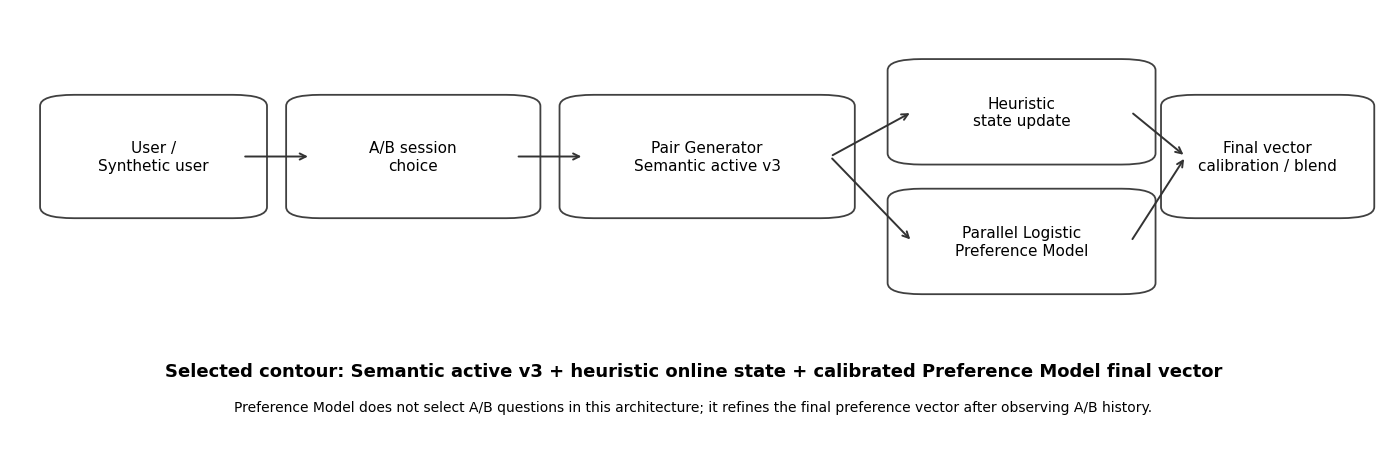

In [4]:
plot_final_architecture_diagram(
    FIGURES_DIR / 'article_final_architecture_pipeline.png'
)

## 2. Запуск финального эксперимента

Эксперимент фиксирует Pair Generator как `semantic_active_v21`, а затем сравнивает варианты итогового preference vector:

- `Heuristic update`;
- `Raw Preference Model`;
- `Norm-calibrated PM`;
- `Train-scale PM`;
- `Blend 70% heuristic + 30% PM`;
- `Blend 50% heuristic + 50% PM`.

Основная рабочая рекомендация: использовать **blend 70/30** как устойчивый вариант, а `Norm-calibrated PM` рассматривать как лучший ablation на `Archetype 8D`.

In [5]:
dataset = load_synthetic_users_dataset(DATASET_PATH)
print(dataset['target_mode'].value_counts())
dataset.head()

target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64


,user_id,target_mode,noise_std,z_sub_bass,z_bass,z_lowmid,z_warmth,z_presence,z_clarity,z_air,z_brightness,importance_sub_bass,importance_bass,importance_lowmid,importance_warmth,importance_presence,importance_clarity,importance_air,importance_brightness,main_archetype,secondary_archetype,is_extreme_archetype,intensity_label,intensity_value,semantic_low_power,semantic_warmth_body,semantic_presence_clarity,semantic_air_brightness,semantic6d_low_power,semantic6d_warmth_body,semantic6d_presence_clarity,semantic6d_air_brightness,semantic6d_club_energy,semantic6d_clean_bass,main_weight,secondary_weight,mix_neutral,mix_bass_lover,mix_warm,mix_bright,mix_v_shape,mix_mid_forward,mix_soft_dark,mix_detail_focused,mix_basshead,mix_extreme_vshape,mix_club_curve,mix_sparkle_lover
0,0,random8d,0.05,0.243774,-0.831987,0.600361,0.752452,-1.560828,-1.041744,0.102272,-0.252994,0.900239,0.671810,1.231921,1.188881,0.926720,1.343556,1.066533,0.670342,none,none,False,random,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,random8d,0.05,0.295001,-0.767106,0.702760,-0.039941,-0.147890,-0.544744,0.978033,-0.123624,0.733537,0.753362,1.026695,0.968451,0.984613,0.990866,1.803292,0.739184,none,none,False,random,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,random8d,0.05,-0.409794,-0.651018,0.492784,0.903178,-0.091158,-0.672125,-0.659585,0.520474,1.160387,1.081900,0.708707,0.970321,0.931886,0.965756,1.213629,0.967416,none,none,False,random,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,random8d,0.05,0.543131,0.054063,0.231296,0.505031,-1.165725,-0.255737,-0.376298,-0.511102,0.857972,1.594157,0.697728,1.325796,0.524196,0.840218,1.000079,1.159853,none,none,False,random,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,random8d,0.05,0.568981,0.634678,-0.278980,-0.369881,0.686381,-0.153043,-1.020549,-0.906630,0.698663,1.147089,1.013156,1.227391,0.830010,1.018886,1.199827,0.864979,none,none,False,random,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Для быстрого теста можно временно заменить dataset на маленькую выборку:
# dataset = dataset.groupby('target_mode', group_keys=False).head(5).reset_index(drop=True)

sessions, heldout_pairs, train_steps = run_preference_model_calibration_batch_v4a2(
    dataset=dataset,
    n_steps=25,
    n_heldout_pairs=100,
    pair_strategy='semantic_active_v21',
    step_scale=0.6,
    heuristic_lr=0.25,
    model_lr=0.06,
    model_temperature=0.75,
    model_l2=0.003,
    model_feature_weight='uniform',
)

summary = summarize_final_architecture(sessions)
improvement = compare_methods_vs_heuristic(sessions)
improvement_summary = summarize_method_improvements(improvement)

save_final_architecture_tables(
    sessions=sessions,
    heldout_pairs=heldout_pairs,
    train_steps=train_steps,
    summary=summary,
    improvement=improvement,
    improvement_summary=improvement_summary,
    output_dir=TABLES_DIR,
    prefix='article_final_architecture',
)

summary.head()

,target_mode,target_mode_display,method,method_display,users,mean_final_distance,std_final_distance,mean_cosine_to_target,mean_heldout_accuracy,mean_heldout_log_loss,mean_vector_norm
0,archetype8d,Archetype 8D,blend_50h_50m,Blend 50/50,100,0.352551,0.162526,0.920683,0.6327,0.675953,1.156775
1,archetype8d,Archetype 8D,blend_70h_30m,Selected: Blend 70/30,100,0.353827,0.147188,0.911927,0.6327,0.682011,1.124635
2,archetype8d,Archetype 8D,heuristic_update,Heuristic update,100,0.374691,0.133219,0.893582,0.4974,0.693148,1.080509
3,archetype8d,Archetype 8D,norm_calibrated_model,Norm-calibrated PM,100,0.347072,0.171199,0.929964,0.6455,0.669253,1.080509
4,archetype8d,Archetype 8D,raw_preference_model,Raw Preference Model,100,0.531560,0.321433,0.929964,0.6247,0.679746,0.634486


## 3. Сводная таблица по финальному вектору

In [7]:
summary.sort_values(['target_mode', 'mean_final_distance']).reset_index(drop=True)

,target_mode,target_mode_display,method,method_display,users,mean_final_distance,std_final_distance,mean_cosine_to_target,mean_heldout_accuracy,mean_heldout_log_loss,mean_vector_norm
0,archetype8d,Archetype 8D,norm_calibrated_model,Norm-calibrated PM,100,0.347072,0.171199,0.929964,0.6455,0.669253,1.080509
1,archetype8d,Archetype 8D,blend_50h_50m,Blend 50/50,100,0.352551,0.162526,0.920683,0.6327,0.675953,1.156775
2,archetype8d,Archetype 8D,blend_70h_30m,Selected: Blend 70/30,100,0.353827,0.147188,0.911927,0.6327,0.682011,1.124635
3,archetype8d,Archetype 8D,heuristic_update,Heuristic update,100,0.374691,0.133219,0.893582,0.4974,0.693148,1.080509
4,archetype8d,Archetype 8D,train_scale_model,Train-scale PM,100,0.391975,0.215620,0.929924,0.6327,0.665156,1.245125
5,archetype8d,Archetype 8D,raw_preference_model,Raw Preference Model,100,0.531560,0.321433,0.929964,0.6247,0.679746,0.634486
6,random8d,Random 8D,heuristic_update,Heuristic update,100,1.518166,0.488628,0.690129,0.5076,0.693138,1.543411
7,random8d,Random 8D,blend_70h_30m,Selected: Blend 70/30,100,1.523020,0.490006,0.691047,0.5253,0.690077,1.617680
8,random8d,Random 8D,blend_50h_50m,Blend 50/50,100,1.534701,0.490437,0.690120,0.5253,0.690758,1.670431
9,random8d,Random 8D,norm_calibrated_model,Norm-calibrated PM,100,1.549718,0.490313,0.683196,0.5224,0.689903,1.543411


In [8]:
improvement_summary.sort_values(['target_mode', 'mean_improvement_pct'], ascending=[True, False]).reset_index(drop=True)

,target_mode,target_mode_display,method,method_display,users,mean_heuristic_final_distance,mean_method_final_distance,mean_improvement_abs,mean_improvement_pct,win_rate_vs_heuristic
0,archetype8d,Archetype 8D,norm_calibrated_model,Norm-calibrated PM,100,0.374691,0.347072,0.027618,8.163884,0.70
1,archetype8d,Archetype 8D,blend_50h_50m,Blend 50/50,100,0.374691,0.352551,0.022140,6.901198,0.73
2,archetype8d,Archetype 8D,blend_70h_30m,Selected: Blend 70/30,100,0.374691,0.353827,0.020864,6.333303,0.78
3,archetype8d,Archetype 8D,train_scale_model,Train-scale PM,100,0.374691,0.391975,-0.017284,-4.177773,0.57
4,archetype8d,Archetype 8D,raw_preference_model,Raw Preference Model,100,0.374691,0.531560,-0.156869,-41.977616,0.31
5,random8d,Random 8D,blend_70h_30m,Selected: Blend 70/30,100,1.518166,1.523020,-0.004854,-0.341502,0.40
6,random8d,Random 8D,blend_50h_50m,Blend 50/50,100,1.518166,1.534701,-0.016535,-1.257895,0.37
7,random8d,Random 8D,norm_calibrated_model,Norm-calibrated PM,100,1.518166,1.549718,-0.031551,-2.495083,0.35
8,random8d,Random 8D,train_scale_model,Train-scale PM,100,1.518166,1.589754,-0.071588,-5.642078,0.28
9,random8d,Random 8D,raw_preference_model,Raw Preference Model,100,1.518166,1.712102,-0.193936,-15.626448,0.15


## 4. Итоговые графики для статьи

Дальше идут графики, которые можно использовать в статье/дипломе. Подписи осей оставлены на русском, а названия стратегий и режимов — на английском, чтобы сохранить техническую терминологию.

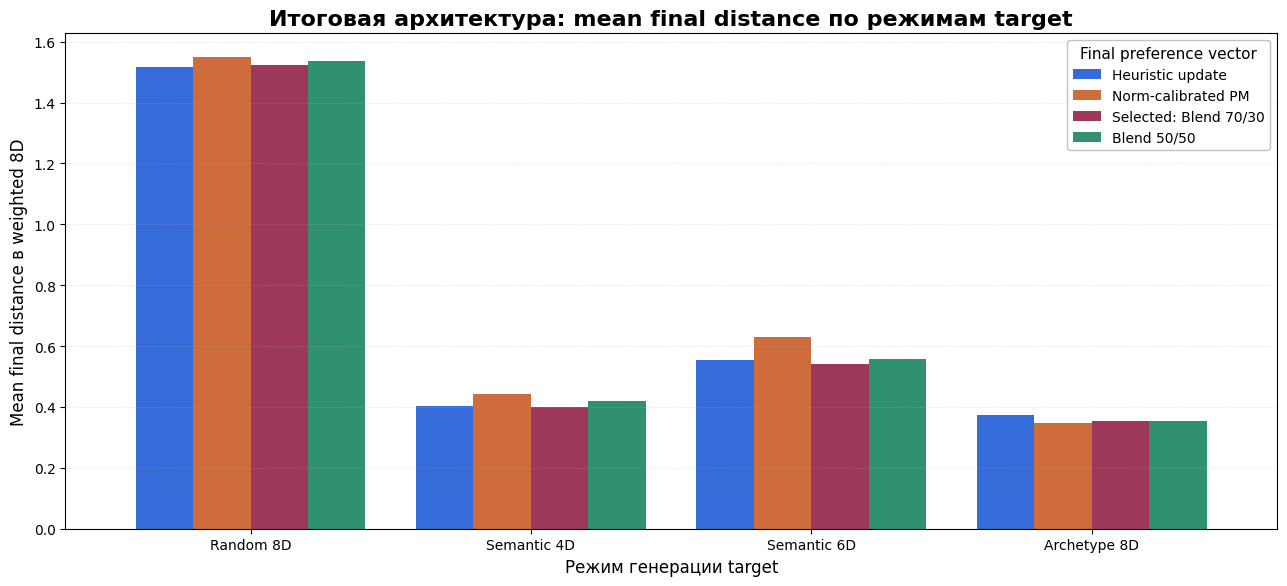

In [9]:
plot_final_distance_by_target(
    summary,
    FIGURES_DIR / 'article_final_architecture_mean_final_distance_by_target.png',
)

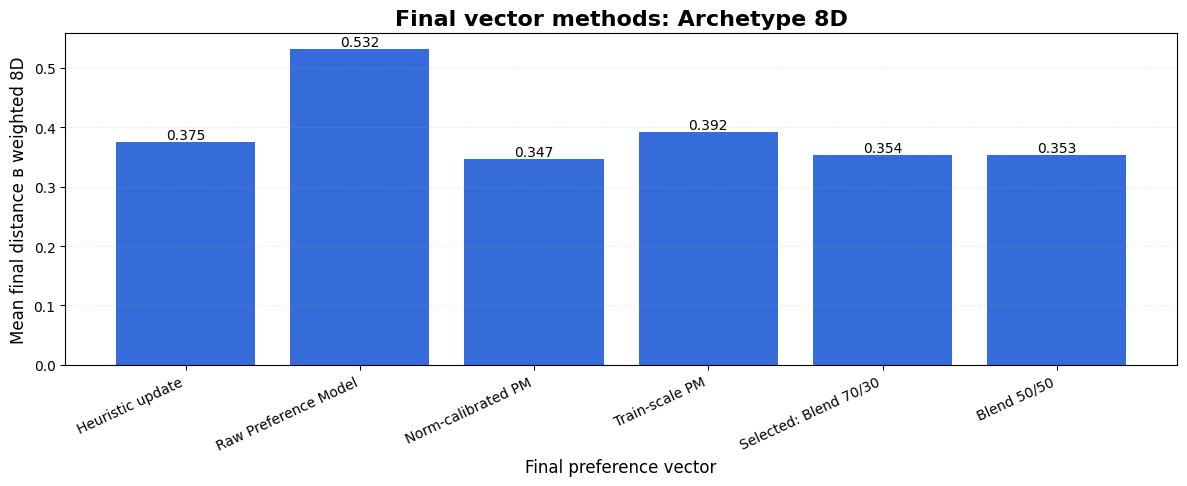

In [10]:
plot_archetype_final_vector_comparison(
    summary,
    FIGURES_DIR / 'article_final_architecture_archetype8d_final_vector_methods.png',
)

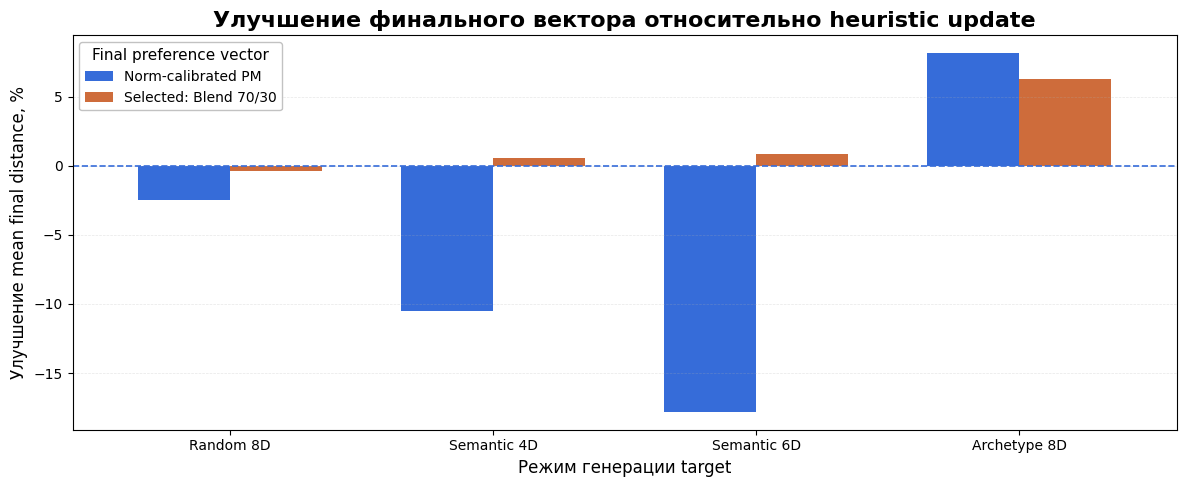

In [11]:
plot_selected_vs_heuristic_improvement(
    improvement_summary,
    FIGURES_DIR / 'article_final_architecture_improvement_vs_heuristic.png',
)

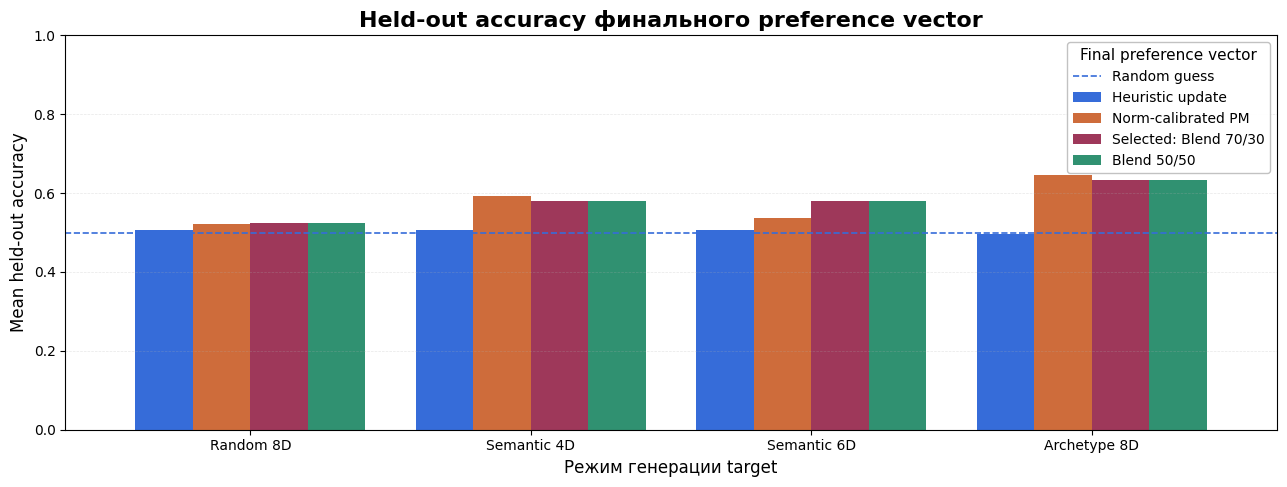

In [12]:
plot_heldout_accuracy_by_target(
    summary,
    FIGURES_DIR / 'article_final_architecture_heldout_accuracy.png',
)

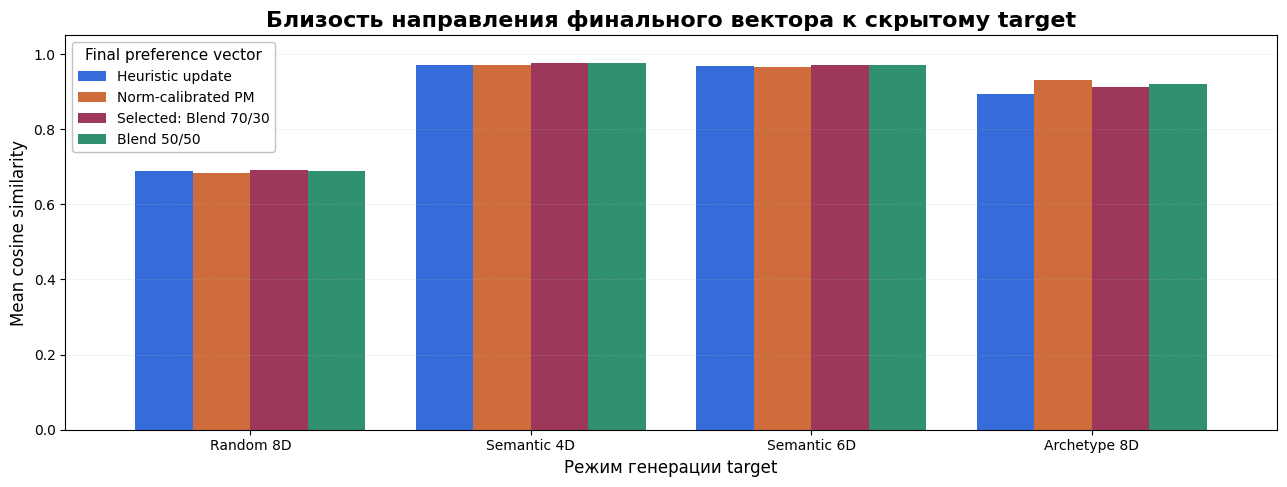

In [13]:
plot_cosine_by_target(
    summary,
    FIGURES_DIR / 'article_final_architecture_cosine_to_target.png',
)

## 5. Короткая интерпретация

Итоговая архитектура выбирается не потому, что Preference Model полностью заменила эвристический контур, а потому что она оказалась полезна как **post-session refinement**.

`Semantic active v3` остаётся основным Pair Generator: предыдущие эксперименты показали, что он лучше всего работает на реалистичном `Archetype 8D` и устойчиво превосходит более общие candidate-pool/model-guided стратегии.

`Logistic Preference Model` обучается параллельно и извлекает направление вкуса из A/B-истории. Raw-вектор модели использовать напрямую не следует, так как модель плохо калибрует масштаб. Но после калибровки или смешивания с heuristic state модель улучшает итоговый preference vector.

Рекомендуемый устойчивый вариант финального вектора:

```text
z_final = 0.7 * z_heuristic + 0.3 * z_model_calibrated
```

Для `Archetype 8D` также полезен ablation `Norm-calibrated PM`, который использует направление Preference Model и масштаб heuristic state.

## Вывод по финальной архитектуре personalization contour

В финальной версии контура персонализации в качестве основного Pair Generator используется `Semantic active v3`, так как ранее он показал наилучшую сходимость на реалистичном режиме `Archetype 8D`. Во время A/B-сессии preference state обновляется эвристическим online update, а параллельно обучается Logistic Preference Model, наблюдающая историю пользовательских A/B-выборов.

Эксперименты показали, что raw-вектор Preference Model не следует использовать напрямую как итоговый preference vector, поскольку модель хорошо восстанавливает направление предпочтений, но хуже калибрует масштаб. Поэтому в финальной архитектуре используется post-session calibration/blend: итоговый вектор строится как комбинация эвристического состояния и калиброванного направления Preference Model.

На режиме `Archetype 8D` выбранный вариант `Blend 70/30` снижает mean final distance относительно `Heuristic update`, а также повышает held-out accuracy и cosine similarity к скрытому target. Это показывает, что Preference Model действительно извлекает дополнительную информацию из A/B-истории и улучшает итоговый preference vector.

При этом Preference Model не используется для выбора A/B-вопросов: эксперименты с model-guided Pair Generator показали, что полное доверие модели при генерации пар ухудшает сходимость. Таким образом, в финальной архитектуре роли разделены: `Semantic active v3` отвечает за выбор информативных A/B-вопросов, heuristic update обеспечивает стабильную online-сходимость, а Preference Model уточняет финальный вектор после накопления истории выборов.